## Problem 1: Neural Networks (ReLU Activation)

The neuron uses the ReLU activation function:

\[
f(x) = \max(0, x)
\]

The pre-activation value is computed as:

\[
z = w_1 x_1 + w_2 x_2 + b
\]

### Calculations

| Case | \(x_1\) | \(x_2\) | \(w_1\) | \(w_2\) | \(b\) | \(z = w_1x_1 + w_2x_2 + b\) | \(f(z)\) |
|------|--------|--------|--------|--------|------|--------------------------------|---------|
| A | 1.0 | 2.0 | 0.5 | 0.3 | -0.2 | \(0.5(1.0) + 0.3(2.0) - 0.2 = 0.9\) | **0.9** |
| B | 1.0 | 2.0 | -0.5 | -0.8 | -0.5 | \(-0.5(1.0) + -0.8(2.0) - 0.5 = -2.6\) | **0** |
| C | 2.0 | 3.0 | -1.0 | -1.0 | -1.0 | \(-1.0(2.0) + -1.0(3.0) - 1.0 = -6\) | **0** |

### (b) Neuron Stopped Activating

Cases **B** and **C** have outputs of **0**, meaning the neuron is effectively **inactive / dead** for those inputs.

### (c) Impact and How to Avoid It

When ReLU neurons repeatedly output zero, they stop updating because the gradient is zero. These neurons become permanently "dead," reducing the model’s ability to learn.

**How to avoid dead neurons:**
- Use **Leaky ReLU**, **ELU**, or **PReLU** instead of standard ReLU.
- Use **He/Kaiming initialization**.
- Avoid strongly negative biases.
- Use **Batch Normalization**.
- Use a **smaller learning rate**.


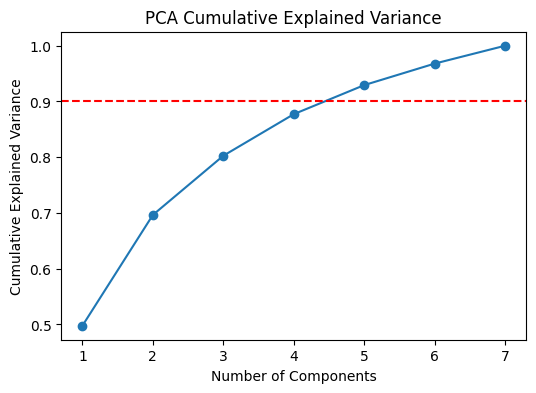

Components needed to reach 90% variance: 5


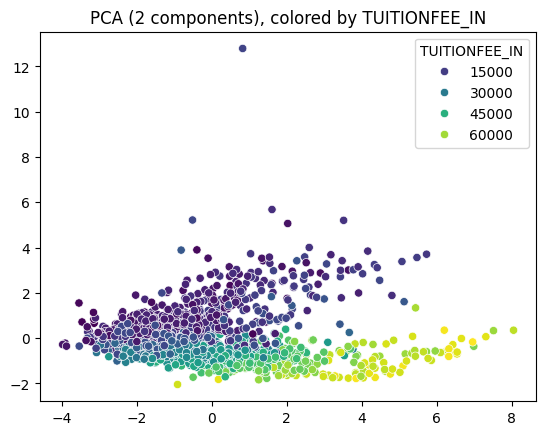

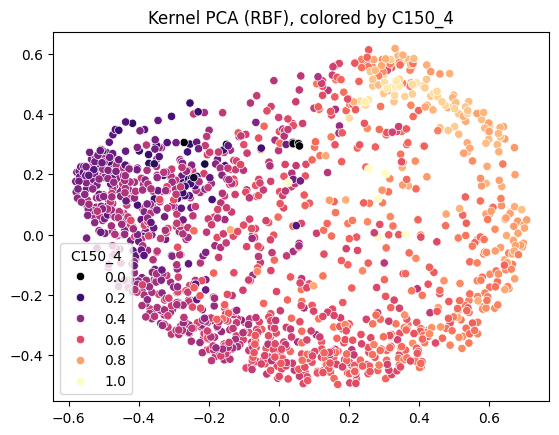

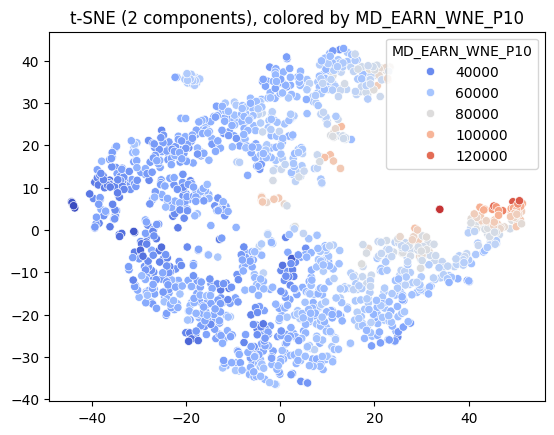

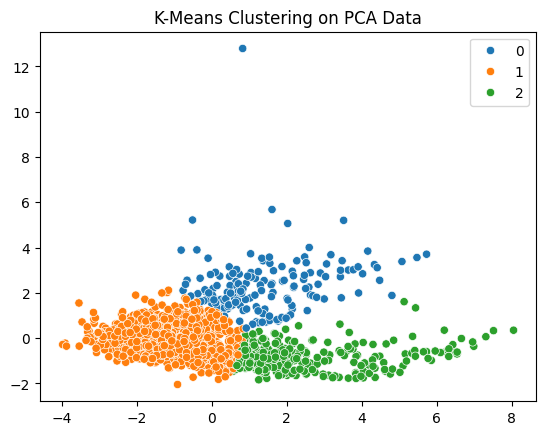

K-Means Silhouette Score: 0.4676882926070153


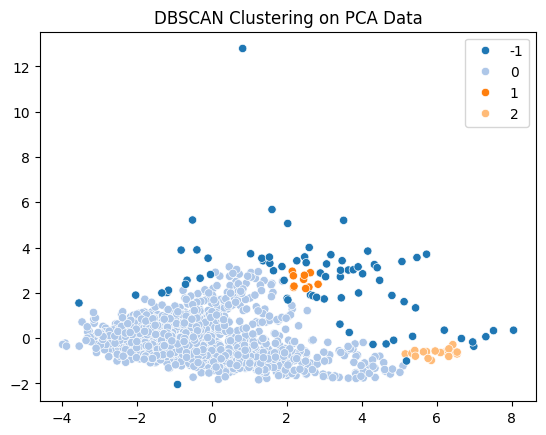

DBSCAN Silhouette Score: 0.37385637012370865


In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent results
RANDOM_STATE = 15

# Load data
df = pd.read_csv("C:\\Users\\unkno\\OneDrive\\Documents\\GitHub\\disgusting-undergrad-busy-work\\CPSC Coursework\\CPSC4300\\Assignment 4\\data\\Most-Recent-US-College-Scorecard.csv", low_memory=False)

# Select required columns
cols = [
    "ADM_RATE", "TUITIONFEE_IN", "C150_4", "MD_EARN_WNE_P10",
    "UGDS", "AVGFACSAL", "PELL_COMP_ORIG_YR6_RT"
]

# Clean + convert data
data = (
    df[cols]
    .replace(["PrivacySuppressed", "PS"], np.nan)
    .apply(pd.to_numeric, errors='coerce')
    .dropna()
)

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(data)

# ------------------- (a) PCA Cumulative Explained Variance -------------------
pca = PCA().fit(X)
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()

print("Components needed to reach 90% variance:", np.argmax(cum_var >= 0.90) + 1)

# Reduce to 2D for scatter plots
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

# ------------------- (b1) PCA Scatter Plot -------------------
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=data["TUITIONFEE_IN"], palette="viridis")
plt.title("PCA (2 components), colored by TUITIONFEE_IN")
plt.show()

# ------------------- (b2) Kernel PCA (RBF) -------------------
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=RANDOM_STATE)
kpca_2d = kpca.fit_transform(X)

sns.scatterplot(x=kpca_2d[:,0], y=kpca_2d[:,1], hue=data["C150_4"], palette="magma")
plt.title("Kernel PCA (RBF), colored by C150_4")
plt.show()

# ------------------- (b3) t-SNE -------------------
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
tsne_2d = tsne.fit_transform(X)

sns.scatterplot(x=tsne_2d[:,0], y=tsne_2d[:,1], hue=data["MD_EARN_WNE_P10"], palette="coolwarm")
plt.title("t-SNE (2 components), colored by MD_EARN_WNE_P10")
plt.show()

# ------------------- (c) Clustering on PCA-reduced data -------------------
# K-Means
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE).fit(pca_2d)
kmeans_labels = kmeans.labels_

sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=kmeans_labels, palette="tab10")
plt.title("K-Means Clustering on PCA Data")
plt.show()

km_sil = silhouette_score(pca_2d, kmeans_labels)
print("K-Means Silhouette Score:", km_sil)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10).fit(pca_2d)
db_labels = dbscan.labels_

sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=db_labels, palette="tab20")
plt.title("DBSCAN Clustering on PCA Data")
plt.show()

db_sil = silhouette_score(pca_2d, db_labels) if len(set(db_labels)) > 1 else "Not Defined (1 cluster)"
print("DBSCAN Silhouette Score:", db_sil)


### (b.4) Comparison of PCA, Kernel PCA, and t-SNE

**PCA (Linear Dimensionality Reduction):**  
PCA projects the data into a lower-dimensional *linear* subspace based on variance.  
In our PCA scatter plot, the data forms an elongated cloud where variation appears mostly along one dominant direction. This means the relationships between the variables are mostly linear. The color gradient based on *tuition (TUITIONFEE_IN)* varies smoothly, indicating tuition cost correlates with the principal components, but the separation is not very strong.

**Kernel PCA (RBF Kernel):**  
Kernel PCA allows for *non-linear* separation by applying a kernel function before performing PCA.  
The Kernel PCA plot shows a curved, ring-like structure, meaning the model is capturing patterns that are not captured in the linear PCA projection. The color pattern for *C150_4 (4-year completion rate)* varies more smoothly across the curved space, meaning Kernel PCA uncovers structure that relates more strongly to completion rate than standard PCA.

**t-SNE (Non-linear Manifold Learning for Visualization):**  
t-SNE focuses on preserving *local neighborhood structure*, making it useful for visualization of clusters.  
The t-SNE plot shows several loosely formed clusters and visible neighborhoods. Schools with higher *MD_EARN_WNE_P10 (median earnings 10 years after entry)* appear grouped, showing stronger separation of institutions by post-graduation earnings. However, the global structure is harder to interpret, which is expected for t-SNE.
